In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!ls /content/drive/MyDrive

Mounted at /content/drive
 20221222_075259.jpg
 20250614_195255.jpg
 anugnareddy1page.pdf
 AWSAcademy12NEW20250928-32-4w76kl.pdf
'Colab Notebooks'
 day.csv
 HEXA-HEADs.ppt.pptx
 HEXA-HEADS.pptx
 hour.csv
 IMG-20250721-WA0002.jpeg
 IMG-20250721-WA0003.jpeg
 Learningmanagementsystem.mp4
'salesforce capstone-handsmen threads'
 Screenshot_20240828_204723_Digilocker.jpg
'Screenshot 2025-10-02 180507.png'
'Screenshot 2025-10-02 180622.png'
 winter_fashion.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

day_df = pd.read_csv("/content/drive/MyDrive/day.csv")
hour_df = pd.read_csv("/content/drive/MyDrive/hour.csv")

day_df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
print(day_df.shape)

(731, 16)


In [ ]:
print(hour_df.shape)

(17379, 17)


In [ ]:
print(day_df.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [ ]:
print(hour_df.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [ ]:
print(hour_df.isnull().sum())
print(day_df.isnull().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


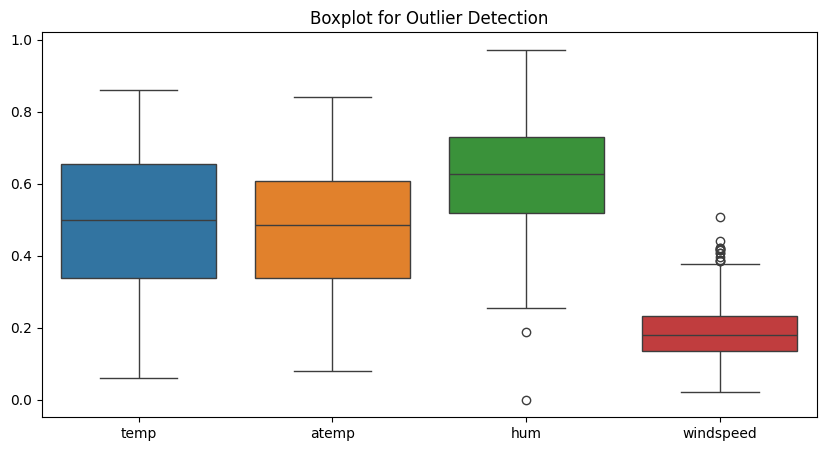

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=day_df[['temp','atemp','hum','windspeed']])
plt.title("Boxplot for Outlier Detection")
plt.show()


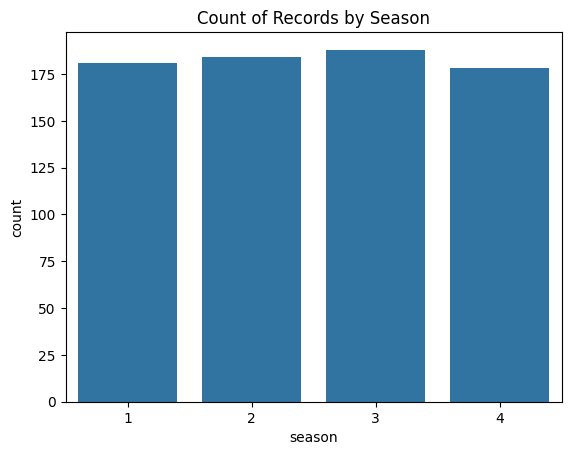

In [ ]:
sns.countplot(x='season', data=day_df)
plt.title("Count of Records by Season")
plt.show()


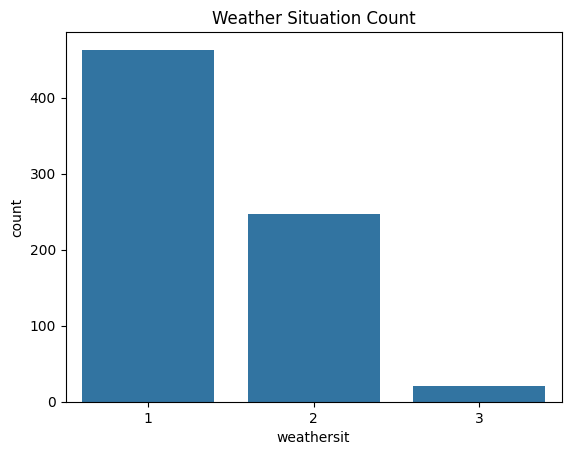

In [ ]:
sns.countplot(x='weathersit', data=day_df)
plt.title("Weather Situation Count")
plt.show()


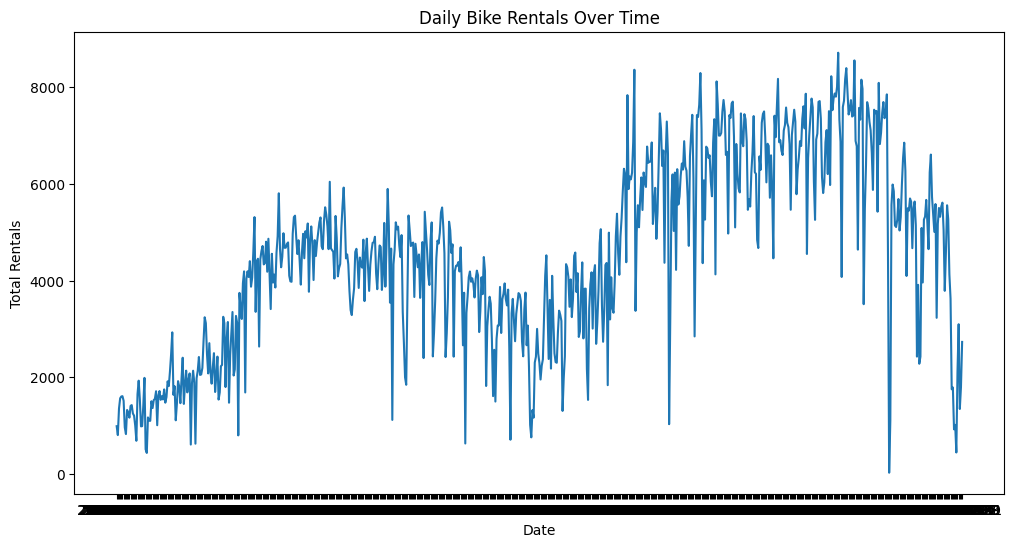

In [ ]:

plt.figure(figsize=(12,6))
plt.plot(day_df['dteday'], day_df['cnt'])
plt.title("Daily Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.show()


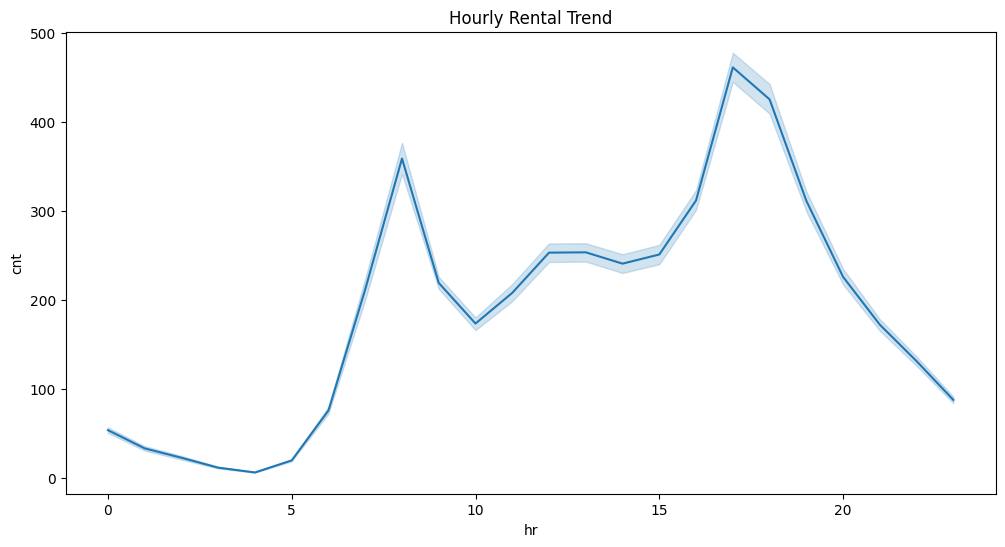

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(x='hr', y='cnt', data=hour_df)
plt.title("Hourly Rental Trend")
plt.show()


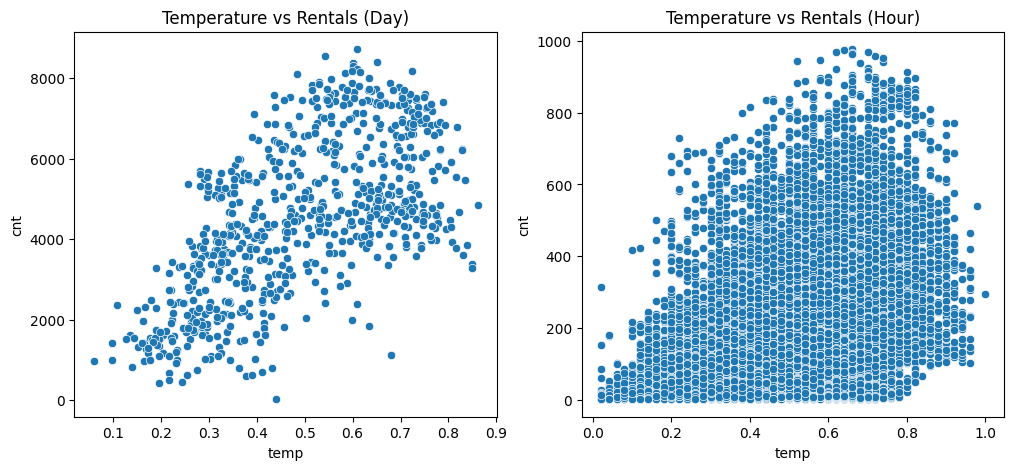

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x='temp', y='cnt', data=day_df)
plt.title("Temperature vs Rentals (Day)")

plt.subplot(1,2,2)
sns.scatterplot(x='temp', y='cnt', data=hour_df)
plt.title("Temperature vs Rentals (Hour)")

plt.show()



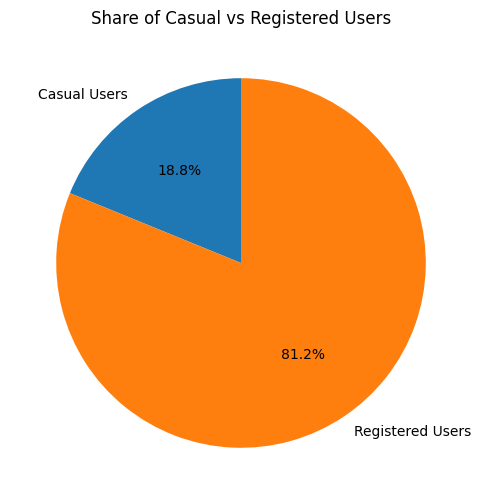

In [ ]:

values = [day_df['casual'].sum(), day_df['registered'].sum()]
labels = ['Casual Users', 'Registered Users']

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Share of Casual vs Registered Users")
plt.show()


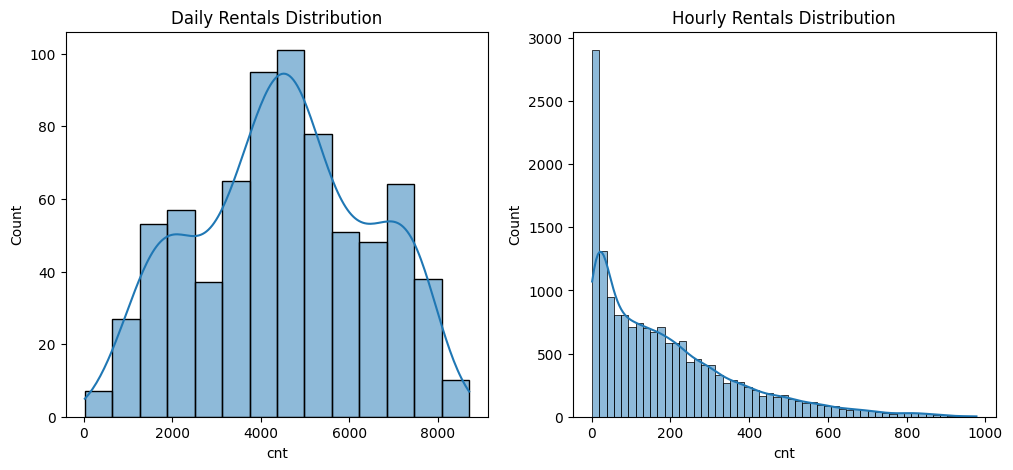

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(day_df['cnt'], kde=True)
plt.title("Daily Rentals Distribution")

plt.subplot(1,2,2)
sns.histplot(hour_df['cnt'], kde=True)
plt.title("Hourly Rentals Distribution")

plt.show()


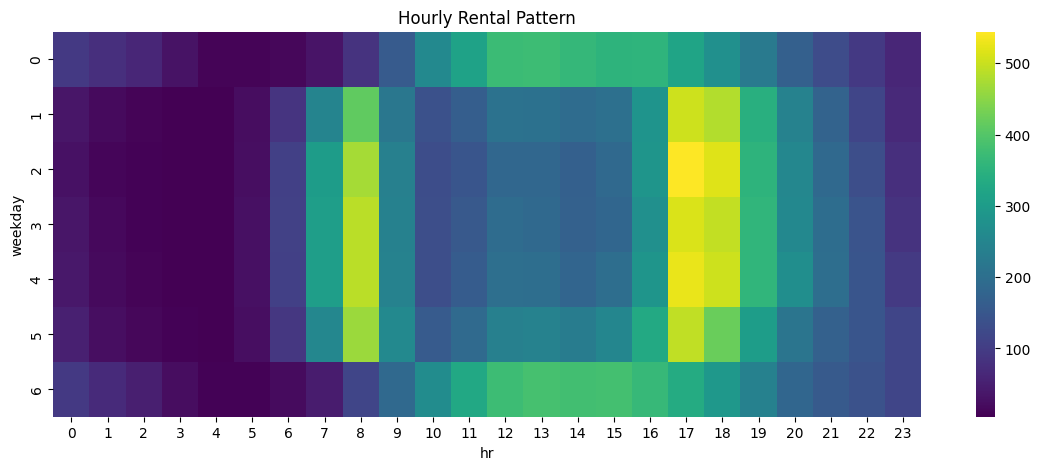

In [ ]:
plt.figure(figsize=(14,5))
pivot_hour = hour_df.pivot_table(index='weekday', columns='hr', values='cnt', aggfunc='mean')
sns.heatmap(pivot_hour, cmap='viridis')
plt.title("Hourly Rental Pattern")
plt.show()


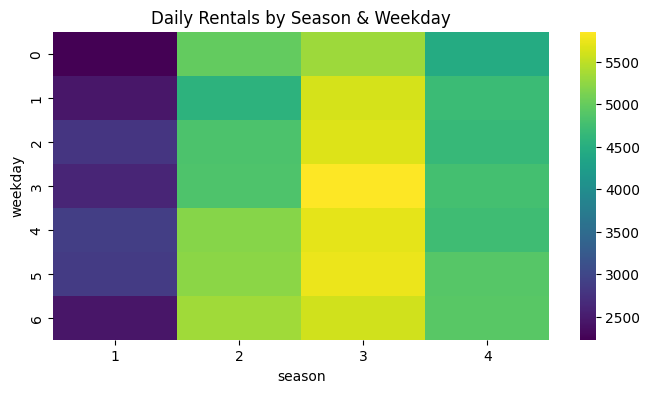

In [ ]:
plt.figure(figsize=(8,4))
pivot_day = day_df.pivot_table(index='weekday', columns='season', values='cnt', aggfunc='mean')
sns.heatmap(pivot_day, cmap='viridis')
plt.title("Daily Rentals by Season & Weekday")
plt.show()


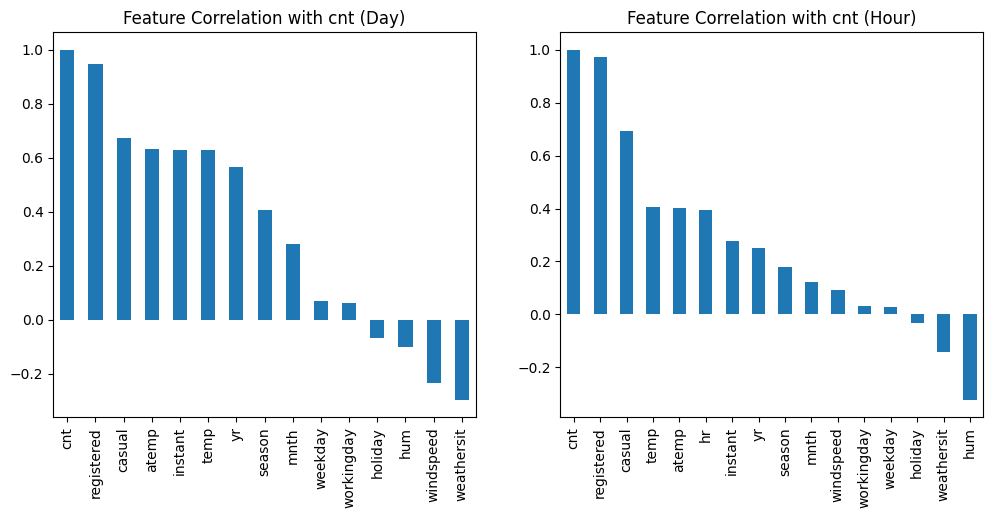

In [ ]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

corr_day = day_df.corr(numeric_only=True)['cnt'].sort_values(ascending=False)
corr_hour = hour_df.corr(numeric_only=True)['cnt'].sort_values(ascending=False)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
corr_day.plot(kind='bar')
plt.title("Feature Correlation with cnt (Day)")

plt.subplot(1,2,2)
corr_hour.plot(kind='bar')
plt.title("Feature Correlation with cnt (Hour)")
plt.show()

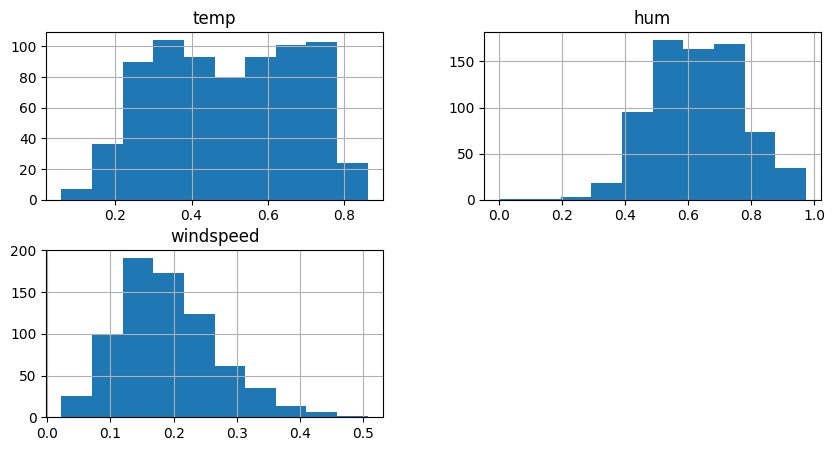

In [ ]:
day_df[['temp','hum','windspeed']].hist(figsize=(10,5))
plt.show()
